In [2]:
!pip install pandas --break-system-packages
!pip install pandas matplotlib --break-system-packages
!pip install seaborn --break-system-packages


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [3]:
import pandas as pd
import seaborn as sns

# Load CSV
df = pd.read_csv("gsmarena_filled.csv")

# --- Step 1: Extract Brand ---
def extract_brand(name):
    words = name.split()
    if len(words[0]) == 1 and len(words) > 1:
        return f"{words[0]} {words[1]}"
    return words[0]

df["Brand"] = df["Name"].apply(extract_brand)

# --- Step 2: Filter out feature phones ---
non_smartphone_keywords = [
    "KaiOS",
    "Nokia Asha",
    "Proprietary",
    "RTOS",
    "MediaTek MT6235",
    "LiMo OS",
    "Linux-based LiMo",
    "Linux / Java-based MOTOMAGX",
    "Unknown"
]

mask = ~df['Platform - OS'].str.contains('|'.join(non_smartphone_keywords), case=False, na=False)
df = df[mask]

# --- Step 3: Move 'Brand' to front and 'URL' to last ---
cols = ["Brand"] + [col for col in df.columns if col not in ["Brand", "URL"]] + ["URL"]
df = df[cols]

# Preview results
print("Both Feature and smart phones :", len(pd.read_csv("gsmarena_filled.csv")))
print("Only Smart phones :", len(df))
df.head()




Both Feature and smart phones : 7125
Only Smart phones : 5432


,Brand,Name,Network - Technology,Launch - Announced,Launch - Status,Body - Dimensions,Body - Weight,Body - SIM,Display - Type,Display - Size,...,Comms - USB,Features - Sensors,Battery - Type,Battery - Talk time,Battery - Music play,Misc - Colors,Misc - Models,SAR EU,Price,URL
0,Acer,Acer Betouch E400-3154,GSM / HSPA,"2010, February. Released 2010, April",Discontinued,115 x 59.3 x 12 mm (4.53 x 2.33 x 0.47 in),125 g (4.41 oz),Mini-SIM,"TFT resistive touchscreen, 256K colors","3.2 inches, 30.5 cm2 (~44.7% screen-to-body ra...",...,2.0,"Accelerometer, compass",Removable Li-Po 1090 mAh battery,Up to 5 h,Unknown,"Soft-touch Black, Ceramic White and Pearl Red ...",Unknown,Unknown,About 80 EUR,https://www.gsmarena.com/acer_betouch_e400-315...
1,Xiaomi,Xiaomi Mi 1s-4929,GSM / HSPA,"2012, August. Released 2012, August",Discontinued,125 x 63 x 11.9 mm (4.92 x 2.48 x 0.47 in),149 g (5.26 oz),Mini-SIM,TFT,"4.0 inches, 44.1 cm2 (~56.0% screen-to-body ra...",...,microUSB 2.0,"Accelerometer, proximity, compass",Removable Li-Ion 1930 mAh battery,Unknown,Unknown,"White, green, blue, red, violet, orange, gray",Unknown,Unknown,About 190 EUR,https://www.gsmarena.com/xiaomi_mi_1s-4929.php
2,Lg,Lg Joy-7054,GSM / HSPA / LTE,"2015, February. Released 2015, May",Discontinued,122.7 x 64 x 11.9 mm (4.83 x 2.52 x 0.47 in),128 g (4.52 oz),Micro-SIM,TFT,"4.0 inches, 45.5 cm2 (~58.0% screen-to-body ra...",...,microUSB 2.0,Accelerometer,"Li-Ion 1900 mAh, removable",Unknown,Unknown,"Dark blue, White",H220,Unknown,About 90 EUR,https://www.gsmarena.com/lg_joy-7054.php
3,Blackberry,Blackberry Evolve X-9282,GSM / HSPA / LTE,"2018, August. Released 2018, August",Discontinued,159.1 x 76.8 x 8.8 mm (6.26 x 3.02 x 0.35 in),170 g (5.93 oz),Nano-SIMNano-SIM + Nano-SIM,IPS LCD,"5.99 inches, 92.6 cm2 (~75.8% screen-to-body r...",...,"USB Type-C 2.0, OTG","Fingerprint (rear-mounted), accelerometer, gyr...","Li-Ion 4000 mAh, non-removable",Unknown,Unknown,Black,Unknown,Unknown,About 350 EUR,https://www.gsmarena.com/blackberry_evolve_x-9...
4,Samsung,Samsung I929 Galaxy S Ii Duos-4387,GSM / CDMA / EVDO,"2011, December. Released 2012, September",Discontinued,129.8 x 68.9 x 9.7 mm (5.11 x 2.71 x 0.38 in),138 g (4.87 oz),"Dual SIM (Mini-SIM, dual stand-by)",Super AMOLED Plus,"4.52 inches, 58.2 cm2 (~65.0% screen-to-body r...",...,"microUSB 2.0 (MHL TV-out), OTG","Accelerometer, gyro, proximity, compass",Removable Li-Ion 1800 mAh battery,Unknown,Unknown,Black,Unknown,Unknown,About 190 EUR,https://www.gsmarena.com/samsung_i929_galaxy_s...


In [4]:
# NFC
df['Has_NFC'] = df['Comms - NFC'].str.contains('Yes', case=False, na=False)

# Fingerprint
df['Has_Fingerprint'] = df['Features - Sensors'].str.contains('fingerprint', case=False, na=False)

# Android 8+
df['Android_8_plus'] = df['Platform - OS'].str.extract(r'Android (\d+)')
df['Android_8_plus'] = pd.to_numeric(df['Android_8_plus'], errors='coerce') >= 8
df['Year'] = df['Launch - Announced'].str.extract(r'(\d{4})')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce').astype('Int64')

# Check if the column exists and has values
print(df[['Launch - Announced', 'Year']].head())

                         Launch - Announced  Year
0      2010, February. Released 2010, April  2010
1       2012, August. Released 2012, August  2012
2        2015, February. Released 2015, May  2015
3       2018, August. Released 2018, August  2018
4  2011, December. Released 2012, September  2011


    Year  NFC_Proportion  Fingerprint_Proportion  Android8plus_Proportion
0   2003        0.000000                0.000000                 0.000000
1   2004        0.000000                0.000000                 0.000000
2   2005        0.000000                0.000000                 0.000000
3   2006        0.000000                0.000000                 0.000000
4   2007        0.000000                4.705882                 0.000000
5   2008        0.000000                0.000000                 0.000000
6   2009        0.000000                1.960784                 0.000000
7   2010        0.591716                0.591716                 0.000000
8   2011       10.071942                0.719424                 0.000000
9   2012       27.953890                0.000000                 0.000000
10  2013       20.767494                0.225734                 0.000000
11  2014       28.519196                3.839122                 0.000000
12  2015       27.356322              

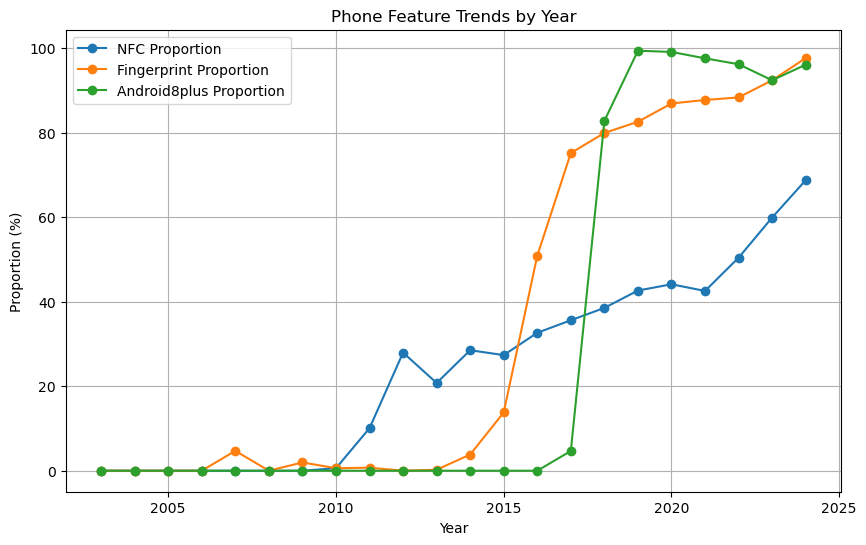

In [5]:
# Snapdragon 660+
# def is_snapdragon_660_plus(chip):
#     if pd.isna(chip):
#         return False
#     chip = chip.lower()
#     if "snapdragon" in chip:
#         nums = [int(s) for s in chip.split() if s.isdigit()]
#         return any(n >= 660 for n in nums)
#     return False

#df['Snapdragon_660_plus'] = df['Platform - Chipset'].apply(is_snapdragon_660_plus)

# --- Group & calculate proportions ---
trend_df = df.groupby('Year').agg(
    NFC_Proportion=('Has_NFC', 'mean'),
    Fingerprint_Proportion=('Has_Fingerprint', 'mean'),
    Android8plus_Proportion=('Android_8_plus', 'mean'),
    #Snapdragon660plus_Proportion=('Snapdragon_660_plus', 'mean')
).reset_index()

# Convert to percentages
trend_df.iloc[:, 1:] = trend_df.iloc[:, 1:] * 100

print(trend_df)

# --- Optional: Visualization ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
for col in trend_df.columns[1:]:
    plt.plot(trend_df['Year'], trend_df[col], marker='o', label=col.replace('_', ' '))

plt.title("Phone Feature Trends by Year")
plt.xlabel("Year")
plt.ylabel("Proportion (%)")
plt.legend()
plt.grid(True)
plt.show()

<Figure size 1400x800 with 0 Axes>

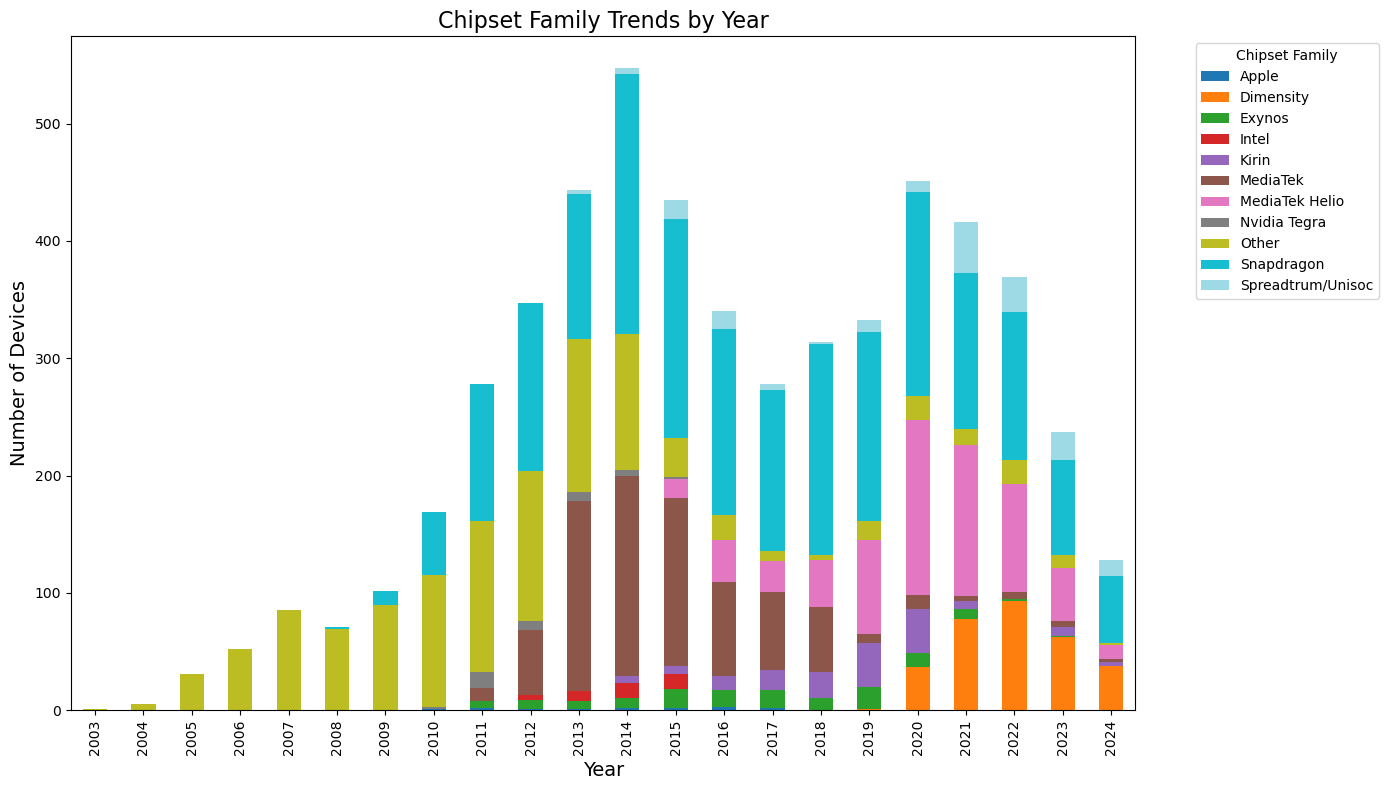

In [6]:
# Ensure Year is numeric
# df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# --- Extract chipset family ---
def get_chipset_family(chipset):
    if pd.isna(chipset):
        return "Unknown"
    chipset = chipset.lower()
    if "snapdragon" in chipset:
        return "Snapdragon"
    elif "exynos" in chipset:
        return "Exynos"
    elif "kirin" in chipset:
        return "Kirin"
    elif "dimensity" in chipset:
        return "Dimensity"
    elif "helio" in chipset:
        return "MediaTek Helio"
    elif "mediatek" in chipset:
        return "MediaTek"
    elif "spreadtrum" in chipset or "unisoc" in chipset:
        return "Spreadtrum/Unisoc"
    elif "apple" in chipset or "bionic" in chipset:
        return "Apple"
    elif "intel" in chipset:
        return "Intel"
    elif "nvidia" in chipset or "tegra" in chipset:
        return "Nvidia Tegra"
    else:
        return "Other"

df["Chipset_Family"] = df["Platform - Chipset"].apply(get_chipset_family)


# --- Group and count ---
chipset_counts = (
    df.groupby(["Year", "Chipset_Family"])
    .size()
    .reset_index(name="Count")
)

# --- Pivot for stacked bar ---
chipset_pivot = chipset_counts.pivot(index="Year", columns="Chipset_Family", values="Count").fillna(0)

# --- Plot ---
plt.figure(figsize=(14, 8))
chipset_pivot.plot(kind="bar", stacked=True, colormap="tab20", figsize=(14, 8))
plt.title("Chipset Family Trends by Year", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Number of Devices", fontsize=14)
plt.legend(title="Chipset Family", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()




=== Top 10 Riskiest Devices ===
                     Name   Year  Risk_Score  Removable_Battery  No_Biometric  Low_RAM  No_NFC
     Blackberry 7230-1009 2003.0           4               True          True     True    True
           Nokia 3230-923 2004.0           4               True          True     True    True
           Nokia 9500-678 2004.0           4               True          True     True    True
       Hp Ipaq H6325-1310 2004.0           4               True          True     True    True
           I Mate Jam-963 2004.0           4               True          True     True    True
       Hp Ipaq H6320-1311 2004.0           4               True          True     True    True
       I Mate Jasjar-1262 2005.0           4               True          True     True    True
Gigabyte Gsmart 2005-1760 2005.0           4               True          True     True    True
           Nokia N92-1346 2005.0           4               True          True     True    True
         Nokia 93

/tmp/ipykernel_2732/1492568341.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_counts = df.groupby(["Year", "Risk_Level"]).size().unstack(fill_value=0)
/tmp/ipykernel_2732/1492568341.py:78: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


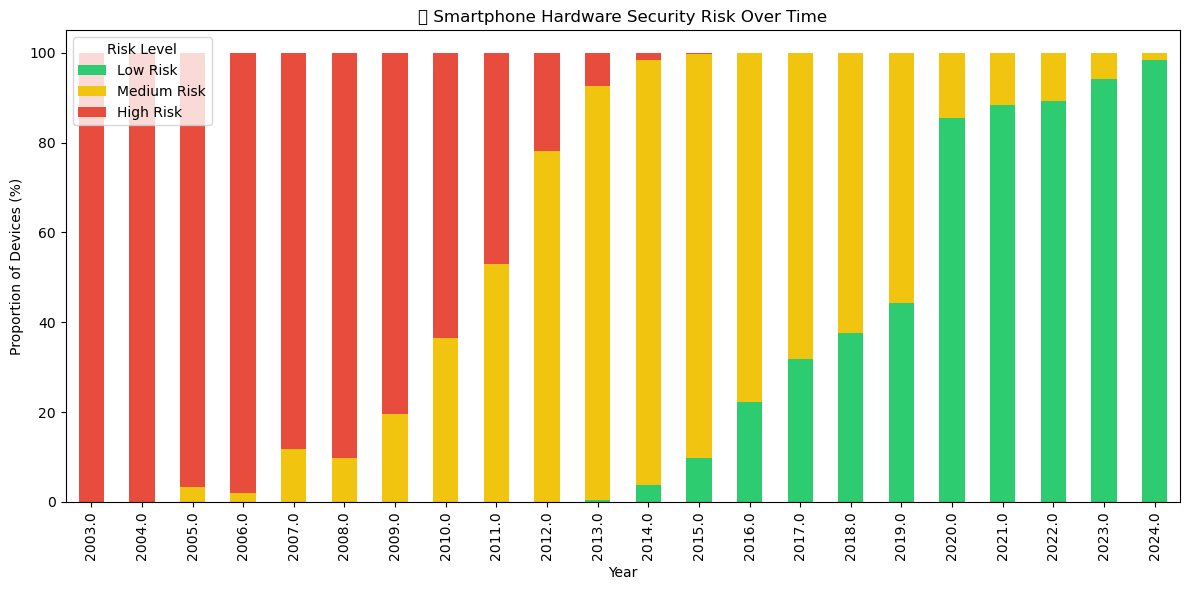

In [7]:

# --- Helper: extract RAM in GB ---
def extract_ram_gb(ram_str):
    if pd.isna(ram_str):
        return 0
    ram_str = ram_str.lower()
    if "gb" in ram_str:
        try:
            return float(ram_str.split("gb")[0].split()[-1])
        except:
            return 0
    elif "mb" in ram_str:
        try:
            return float(ram_str.split("mb")[0].split()[-1]) / 1024
        except:
            return 0
    return 0

df["RAM_GB"] = df["Memory - Internal"].astype(str).apply(extract_ram_gb)

# --- Risk factor detection ---
df["Removable_Battery"] = df["Battery - Type"].str.contains("removable", case=False, na=False)
df["No_Biometric"] = ~df["Features - Sensors"].str.contains("fingerprint|face", case=False, na=False)
df["Low_RAM"] = df["RAM_GB"] < 2
df["No_NFC"] = ~df["Comms - NFC"].str.contains("yes", case=False, na=False)

# --- Risk scoring ---
df["Risk_Score"] = (
    df["Removable_Battery"].astype(int) +
    df["No_Biometric"].astype(int) +
    df["Low_RAM"].astype(int) +
    df["No_NFC"].astype(int)
)

df["Risk_Level"] = pd.cut(
    df["Risk_Score"],
    bins=[-1, 1, 3, 4],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

# --- Extract Year ---
def extract_year(date_str):
    if pd.isna(date_str):
        return None
    try:
        return int(date_str.split(",")[0])
    except:
        return None

df["Year"] = df["Launch - Announced"].apply(extract_year)

# --- Top 10 riskiest devices ---
top_risky = df.sort_values(
    by=["Risk_Score", "Year"],
    ascending=[False, True]
).head(10)[
    ["Name", "Year", "Risk_Score", "Removable_Battery", "No_Biometric", "Low_RAM", "No_NFC"]
]

print("\n=== Top 10 Riskiest Devices ===")
print(top_risky.to_string(index=False))

# --- Group by year ---
risk_counts = df.groupby(["Year", "Risk_Level"]).size().unstack(fill_value=0)
risk_percent = (risk_counts.T / risk_counts.sum(axis=1)).T * 100

# --- Plot ---
risk_percent.plot(
    kind="bar",
    stacked=True,
    color=["#2ecc71", "#f1c40f", "#e74c3c"],
    figsize=(12, 6)
)

plt.ylabel("Proportion of Devices (%)")
plt.xlabel("Year")
plt.title("📊 Smartphone Hardware Security Risk Over Time")
plt.legend(title="Risk Level")
plt.tight_layout()
plt.show()

In [8]:
# # Sample data
# data = [
#     {"Device":"Acer BeTouch E400", "RAM":0.256, "Battery":"Removable", "Biometric":False, "NFC":False},
#     {"Device":"Xiaomi Mi 1s", "RAM":1, "Battery":"Removable", "Biometric":False, "NFC":False},
#     {"Device":"LG Joy", "RAM":0.5, "Battery":"Removable", "Biometric":False, "NFC":False},
#     {"Device":"Blackberry Evolve X", "RAM":6, "Battery":"Non-removable", "Biometric":True, "NFC":False},
#     {"Device":"Oppo Find X2 Lite", "RAM":8, "Battery":"Non-removable", "Biometric":True, "NFC":True},
#     {"Device":"Tecno Spark Go 2021", "RAM":2, "Battery":"Non-removable", "Biometric":True, "NFC":False},
# ]

# df = pd.DataFrame(data)

# # Calculate risk points
# df["Risk_Battery"] = df["Battery"].apply(lambda x: 1 if x=="Removable" else 0)
# df["Risk_Biometric"] = df["Biometric"].apply(lambda x: 0 if x else 1)
# df["Risk_RAM"] = df["RAM"].apply(lambda x: 1 if x <= 2 else 0)
# df["Risk_NFC"] = df["NFC"].apply(lambda x: 0 if x else 1)

# df["Risk_Score"] = df[["Risk_Battery","Risk_Biometric","Risk_RAM","Risk_NFC"]].sum(axis=1)
# df["Risk_Level"] = df["Risk_Score"].apply(lambda x: "Low" if x<=1 else ("Medium" if x==2 else "High"))

# # Count reasons per risk level
# stack_data = df.groupby("Risk_Level")[["Risk_Battery","Risk_Biometric","Risk_RAM","Risk_NFC"]].sum()

# # Plot stacked bar chart
# stack_data.plot(kind="bar", stacked=True, figsize=(8,5), colormap="Set2")
# plt.title("Hardware Capabilities vs Security Risk")
# plt.ylabel("Number of devices")
# plt.xlabel("Risk Level")
# plt.show()

In [9]:
# # Full dataset based on provided data
# data = [
#     {"Device":"Acer BeTouch E400","RAM":0.256,"Battery":"Removable","Biometric":False,"NFC":False},
#     {"Device":"Xiaomi Mi 1s","RAM":1,"Battery":"Removable","Biometric":False,"NFC":False},
#     {"Device":"LG Joy","RAM":0.512,"Battery":"Removable","Biometric":False,"NFC":False},
#     {"Device":"Blackberry Evolve X","RAM":6,"Battery":"Non-removable","Biometric":True,"NFC":False},
#     {"Device":"Samsung I929 Galaxy S II Duos","RAM":1,"Battery":"Removable","Biometric":False,"NFC":False},
#     {"Device":"Oppo Find X2 Lite","RAM":8,"Battery":"Non-removable","Biometric":True,"NFC":True},
#     {"Device":"Tecno Spark Go 2021","RAM":2,"Battery":"Non-removable","Biometric":True,"NFC":False},
#     {"Device":"Sony Xperia Ion Hspa","RAM":1,"Battery":"Non-removable","Biometric":False,"NFC":True},
#     {"Device":"HTC Wildfire E3","RAM":4,"Battery":"Non-removable","Biometric":True,"NFC":False},
# ]

# df = pd.DataFrame(data)

# # Calculate risk points
# df["Risk_Battery"] = df["Battery"].apply(lambda x: 1 if x=="Removable" else 0)
# df["Risk_Biometric"] = df["Biometric"].apply(lambda x: 0 if x else 1)
# df["Risk_RAM"] = df["RAM"].apply(lambda x: 1 if x <= 2 else 0)
# df["Risk_NFC"] = df["NFC"].apply(lambda x: 0 if x else 1)

# df["Risk_Score"] = df[["Risk_Battery","Risk_Biometric","Risk_RAM","Risk_NFC"]].sum(axis=1)
# df["Risk_Level"] = df["Risk_Score"].apply(lambda x: "Low" if x<=1 else ("Medium" if x==2 else "High"))

# # Count reasons per risk level
# stack_data = df.groupby("Risk_Level")[["Risk_Battery","Risk_Biometric","Risk_RAM","Risk_NFC"]].sum()

# # Plot stacked bar chart
# plt.figure(figsize=(10,6))
# stack_data.plot(kind="bar", stacked=True, colormap="Set2")
# plt.title("Hardware Capabilities vs Security Risk")
# plt.ylabel("Number of devices")
# plt.xlabel("Risk Level")
# plt.xticks(rotation=0)
# plt.show()


In [10]:
# import pandas as pd

# df = pd.read_csv("gsmarena_filled.csv")  # or your actual chipset dataset file

# Dynamically detect chipset family
def get_chipset_family(chipset):
    if pd.isna(chipset):
        return "Unknown"
    # Take words before first numeric value
    parts = chipset.split()
    family_parts = []
    for p in parts:
        if any(ch.isdigit() for ch in p):
            break
        family_parts.append(p)
    return " ".join(family_parts) if family_parts else chipset

# Apply transformation
df["Chipset Family"] = df["Platform - Chipset"].apply(get_chipset_family)

# Count number of devices per family
chipset_counts = (
    df["Chipset Family"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "Chipset Family", "Chipset Family": "Chipset - soc"})
)

chipset_counts


,Chipset - soc,count
0,Qualcomm,2031
1,Mediatek,1379
2,Unknown,833
3,Mediatek Dimensity,310
4,Kirin,157
5,Exynos,137
6,TI OMAP,111
7,Unisoc,111
8,Qualcomm Snapdragon,86
9,Spreadtrum,44


In [11]:

# NFC detection
nfc_count = df['Comms - NFC'].astype(str).str.lower().eq('yes').sum()

# Enough memory detection (>= 3GB)
def parse_memory(mem_str):
    if pd.isna(mem_str):
        return 0
    mem_str = str(mem_str).lower()
    for part in mem_str.split(','):
        if 'gb ram' in part:
            try:
                return float(part.strip().split('gb ram')[0].split()[-1])
            except:
                pass
    return 0

df['RAM_GB'] = df['Memory - Internal'].apply(parse_memory)
enough_memory_count = (df['RAM_GB'] >= 3).sum()

# Biometric detection (search in Features - Sensors)
biometric_keywords = ['fingerprint', 'face', 'iris']
biometric_count = df['Features - Sensors'].astype(str).str.lower().apply(
    lambda x: any(keyword in x for keyword in biometric_keywords)
).sum()

# Non-removable battery detection
non_removable_count = df['Battery - Type'].astype(str).str.lower().str.contains('non-removable').sum()

# Create summary table
capability_table = pd.DataFrame({
    "Capability": [
        "NFC",
        "Enough Memory (>=3GB)",
        "Biometric Authentication",
        "Non-removable Battery"
    ],
    "Number of Devices": [
        nfc_count,
        enough_memory_count,
        biometric_count,
        non_removable_count
    ]
})

print(capability_table)

                 Capability  Number of Devices
0                       NFC               1499
1     Enough Memory (>=3GB)               2341
2  Biometric Authentication               2432
3     Non-removable Battery               1711


In [13]:
# --- Brand Statistics ---

brand_stats = df.groupby("Brand").agg(
    Num_Models=("Name", "count"),
    Avg_Year=("Year", "mean"),
    NFC_Rate=("Has_NFC", "mean"),
    Fingerprint_Rate=("Has_Fingerprint", "mean")
).reset_index()

# Convert proportions to %
brand_stats["NFC_Rate"] = (brand_stats["NFC_Rate"] * 100).round(1)
brand_stats["Fingerprint_Rate"] = (brand_stats["Fingerprint_Rate"] * 100).round(1)

# Sort by number of models
brand_stats = brand_stats.sort_values("Num_Models", ascending=False)

brand_stats.head(30)  # top 15 brands


,Brand,Num_Models,Avg_Year,NFC_Rate,Fingerprint_Rate
67,Samsung,488,2013.963039,44.5,27.9
79,Vivo,360,2020.567039,36.1,91.7
42,Lg,270,2014.385185,47.0,25.2
30,Huawei,264,2016.984496,42.4,57.2
47,Motorola,246,2014.991837,33.7,41.5
87,Zte,245,2017.255144,37.1,53.9
29,Htc,242,2012.714876,30.6,16.9
54,Oppo,234,2019.300429,41.0,77.8
82,Xiaomi,209,2019.334928,50.2,83.3
49,Nokia,200,2012.577889,26.0,18.0


In [14]:
# --- Identify devices with TEE support (approximation) ---

def has_tee(chipset):
    if pd.isna(chipset):
        return False
    chipset = chipset.lower()
    
    # Known families with TEE
    if any(keyword in chipset for keyword in ["snapdragon", "exynos", "kirin", "dimensity", "helio", "apple", "bionic"]):
        return True
    if "mediatek" in chipset and "helio" not in chipset:
        return True
    if "unisoc" in chipset or "spreadtrum" in chipset:
        return True
    
    return False

df["Has_TEE"] = df["Platform - Chipset"].apply(has_tee)

# Count how many devices have TEE
print("Devices with TEE:", df["Has_TEE"].sum())
print("Total devices:", len(df))


Devices with TEE: 4258
Total devices: 5432
